### Import Libraries

In [284]:
import pandas as pd # Data processing 
import numpy as np 
import matplotlib.pyplot as plt # Data visualisation
import seaborn as sns # Data visualisation
import missingno as msno # Missing Data - Data visualisation
from collections import Counter #Counting

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

#classifier libraries
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from xgboost import XGBClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Evaluation Metrics
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

# Hyper parameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# SMOTE
from imblearn.over_sampling import SMOTE

In [285]:
df = pd.read_csv("drug200.csv")

In [286]:
df.head(2)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC


In [287]:
df.tail(2)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
198,23,M,NORMAL,NORMAL,14.020,drugX
199,40,F,LOW,NORMAL,11.349,drugX


### Dimensionality of the data set

In [288]:
df.shape

(200, 6)

In [289]:
df.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [290]:
#Data Verification - to check the data type, number of features and rows, missing data etc.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


### Numerical Statistical Analysis

In [291]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [292]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,200.0,44.315000,16.544315,15.000,31.0000,45.0000,58.00,74.000
Na_to_K,200.0,16.084485,7.223956,6.269,10.4455,13.9365,19.38,38.247


In [293]:
null_vals = df.isnull().sum()
null_vals

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

### Exploratory Data Analysis

### Univariate Analysis

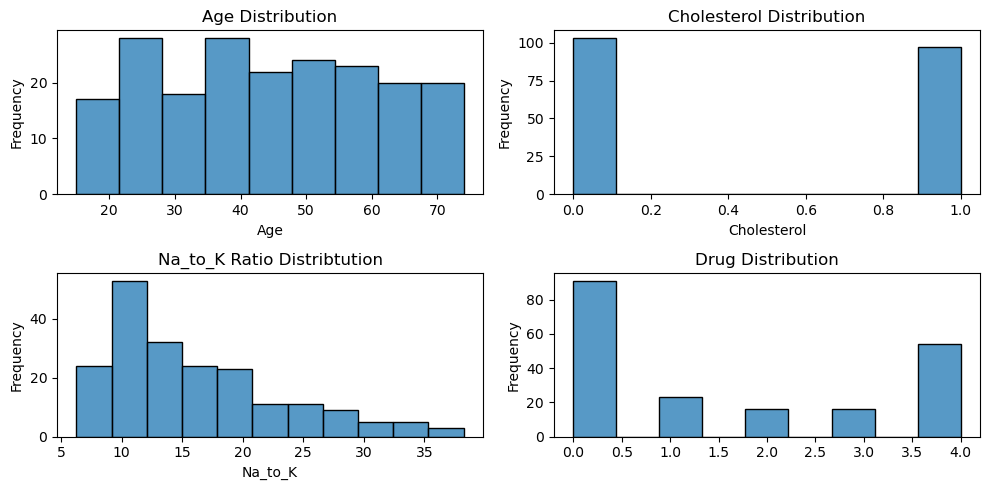

In [343]:
# Create 2 rows × 2 columns of subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 5))

# Age Distribution
sns.histplot(data=df["Age"], ax=axs[0, 0], kde=False)
axs[0, 0].set_title("Age Distribution")
axs[0, 0].set_ylabel("Frequency")

# Cholesterol Distribution
sns.histplot(data=df["Cholesterol"], ax=axs[0, 1], kde=False)
axs[0, 1].set_title("Cholesterol Distribution")
axs[0, 1].set_ylabel("Frequency")

# Na_to_K ratio Distribution
sns.histplot(data=df["Na_to_K"], ax=axs[1, 0], kde=False)
axs[1, 0].set_title("Na_to_K Ratio Distribtution")
axs[1, 0].set_ylabel("Frequency")

# Drug Distribution
sns.histplot(data=df["Drug"].astype('category').cat.codes, ax=axs[1, 1], kde=False)
axs[1, 1].set_title("Drug Distribution")
axs[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Univariate and Bivariate Analysis

In [297]:
df['Sex'].value_counts()

Sex
M    104
F     96
Name: count, dtype: int64

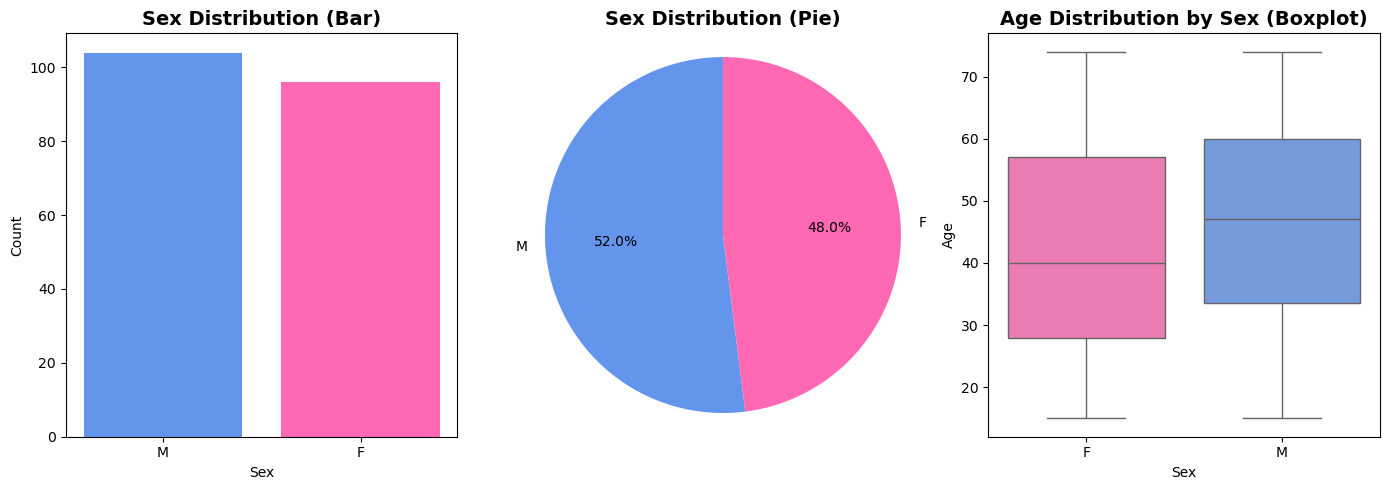

In [298]:
Sex_counts = df['Sex'].value_counts()

fig, axs = plt.subplots(1, 3, figsize=(14, 5))

# Bar plot
axs[0].set_title('Sex Distribution (Bar)', fontsize=14, fontweight='bold')
axs[0].bar(Sex_counts.index, Sex_counts.values, color=['#6495ED', '#FF69B4'])
axs[0].set_xlabel('Sex')
axs[0].set_ylabel('Count')

# Pie Chart 
axs[1].set_title('Sex Distribution (Pie)', fontsize=14, fontweight='bold')
axs[1].pie(Sex_counts.values,
           labels=Sex_counts.index,
           autopct='%1.1f%%',
           colors=['#6495ED', '#FF69B4'],
           startangle=90)
axs[1].axis('equal')

#  Box Plot: Age distribution by BP 
axs[2].set_title('Age Distribution by Sex (Boxplot)', fontsize=14, fontweight='bold')
sns.boxplot(x='Sex', y='Age', data=df, palette=['#FF69B4','#6495ED'], ax=axs[2])
axs[2].set_xlabel('Sex')
axs[2].set_ylabel('Age')

plt.tight_layout()
plt.show()

In [299]:
df['BP'].value_counts()

BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64

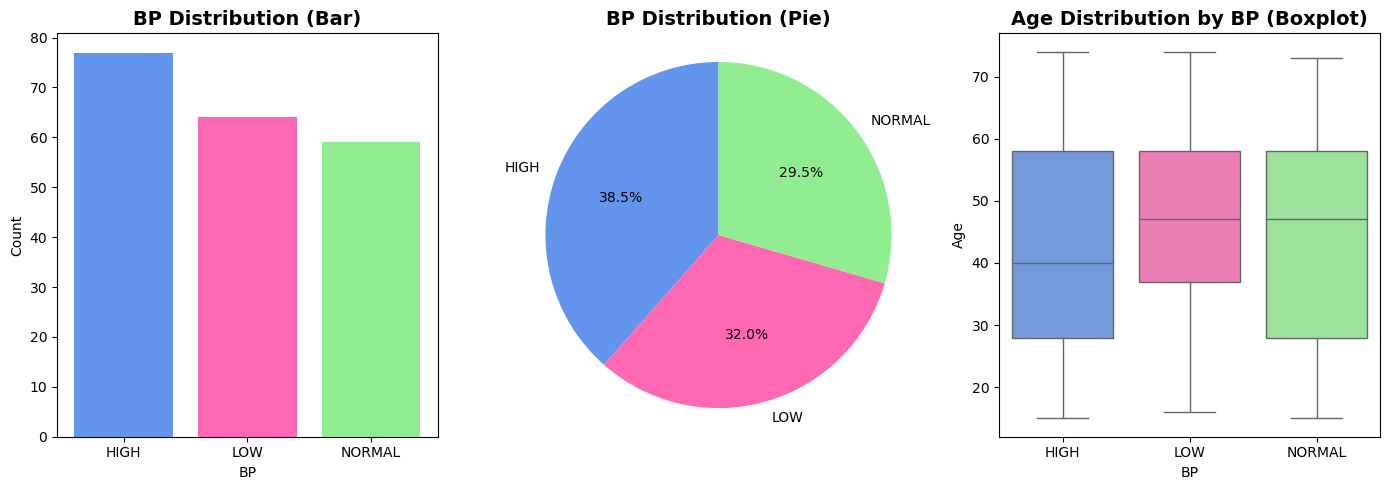

In [300]:
BP_counts = df['BP'].value_counts()

fig, axs = plt.subplots(1, 3, figsize=(14, 5))

# Bar Chart 
axs[0].set_title('BP Distribution (Bar)', fontsize=14, fontweight='bold')
axs[0].bar(BP_counts.index, BP_counts.values, color=['#6495ED', '#FF69B4', '#90EE90'])
axs[0].set_xlabel('BP')
axs[0].set_ylabel('Count')

# Pie Chart 
axs[1].set_title('BP Distribution (Pie)', fontsize=14, fontweight='bold')
axs[1].pie(BP_counts.values,
           labels=BP_counts.index,
           autopct='%1.1f%%',
           colors=['#6495ED', '#FF69B4', '#90EE90'],
           startangle=90)
axs[1].axis('equal')  

#  Box Plot: Age distribution by BP 
axs[2].set_title('Age Distribution by BP (Boxplot)', fontsize=14, fontweight='bold')
sns.boxplot(x='BP', y='Age', data=df, palette=['#6495ED', '#FF69B4', '#90EE90'], ax=axs[2])
axs[2].set_xlabel('BP')
axs[2].set_ylabel('Age')

plt.tight_layout()
plt.show()

In [301]:
df['Cholesterol'].value_counts()

Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64

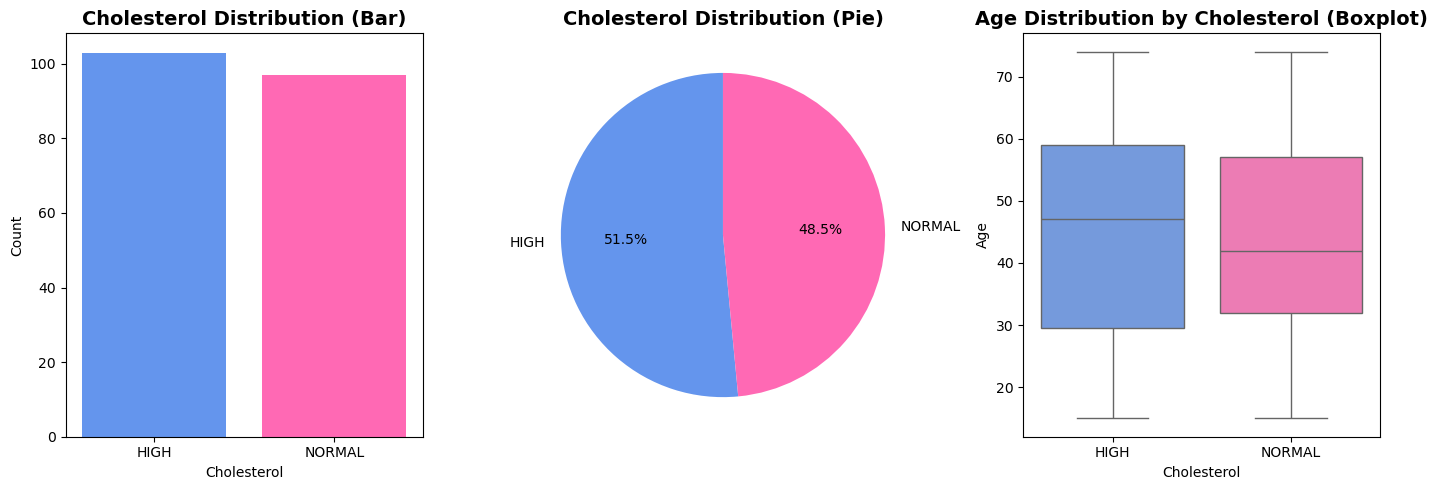

In [302]:
Cholesterol_counts = df['Cholesterol'].value_counts()

fig, axs = plt.subplots(1, 3, figsize=(14, 5))

# Bar Chart 
axs[0].set_title('Cholesterol Distribution (Bar)', fontsize=14, fontweight='bold')
axs[0].bar(Cholesterol_counts.index, Cholesterol_counts.values, color=['#6495ED', '#FF69B4', '#90EE90'])
axs[0].set_xlabel('Cholesterol')
axs[0].set_ylabel('Count')

# Pie Chart 
axs[1].set_title('Cholesterol Distribution (Pie)', fontsize=14, fontweight='bold')
axs[1].pie(Cholesterol_counts.values,
           labels=Cholesterol_counts.index,
           autopct='%1.1f%%',
           colors=['#6495ED', '#FF69B4', '#90EE90'],
           startangle=90)
axs[1].axis('equal') 

# Box Plot: Age distribution by BP 
axs[2].set_title('Age Distribution by Cholesterol (Boxplot)', fontsize=14, fontweight='bold')
sns.boxplot(x='Cholesterol', y='Age', data=df, palette=['#6495ED', '#FF69B4', '#90EE90'], ax=axs[2])
axs[2].set_xlabel('Cholesterol')
axs[2].set_ylabel('Age')

plt.tight_layout()
plt.show()

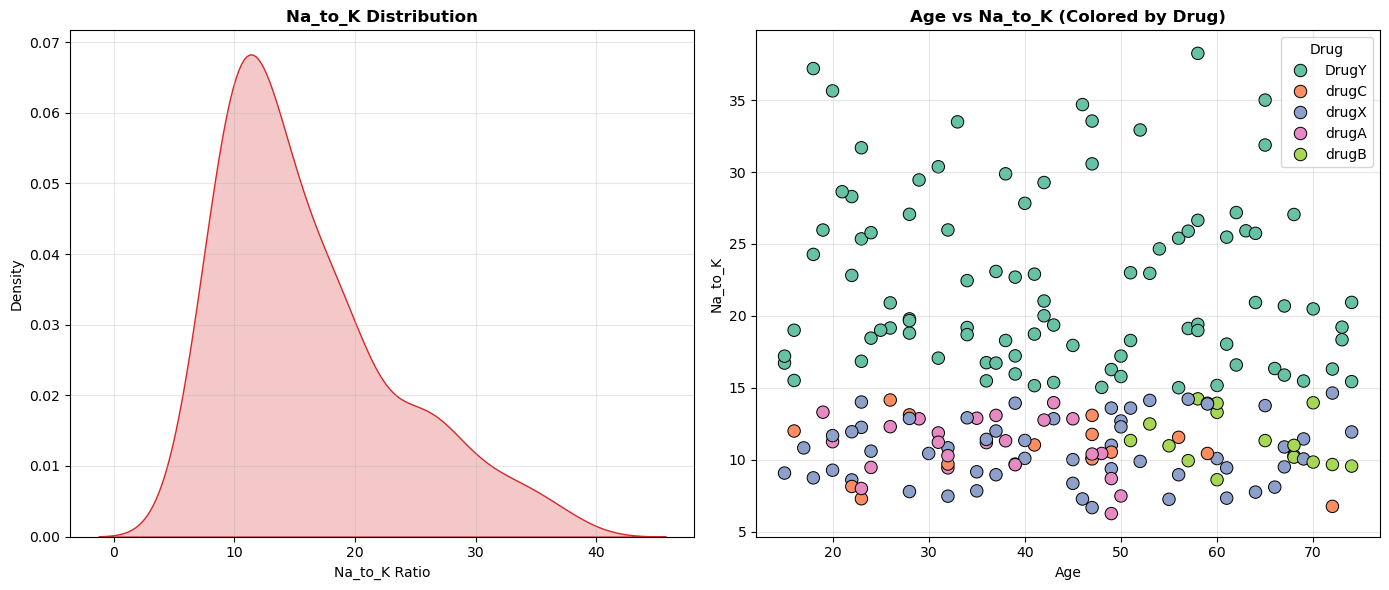

In [303]:
# Create 1 row × 2 columns of subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# KDE Plot of Na_to_K Distribution 
sns.kdeplot(df["Na_to_K"], fill=True, color='#D62728', ax=axs[0])
axs[0].set_title("Na_to_K Distribution", fontsize=12, fontweight='bold')
axs[0].set_xlabel("Na_to_K Ratio")
axs[0].set_ylabel("Density")
axs[0].grid(alpha=0.3)

# Scatter Plot: Age vs Na_to_K colored by Drug 
sns.scatterplot(x='Age', y='Na_to_K', hue='Drug', data=df, palette='Set2', s=80, edgecolor='k', ax=axs[1])
axs[1].set_title("Age vs Na_to_K (Colored by Drug)", fontsize=12, fontweight='bold')
axs[1].set_xlabel("Age")
axs[1].set_ylabel("Na_to_K")
axs[1].legend(title='Drug')
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [304]:
df['Drug'].value_counts()

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

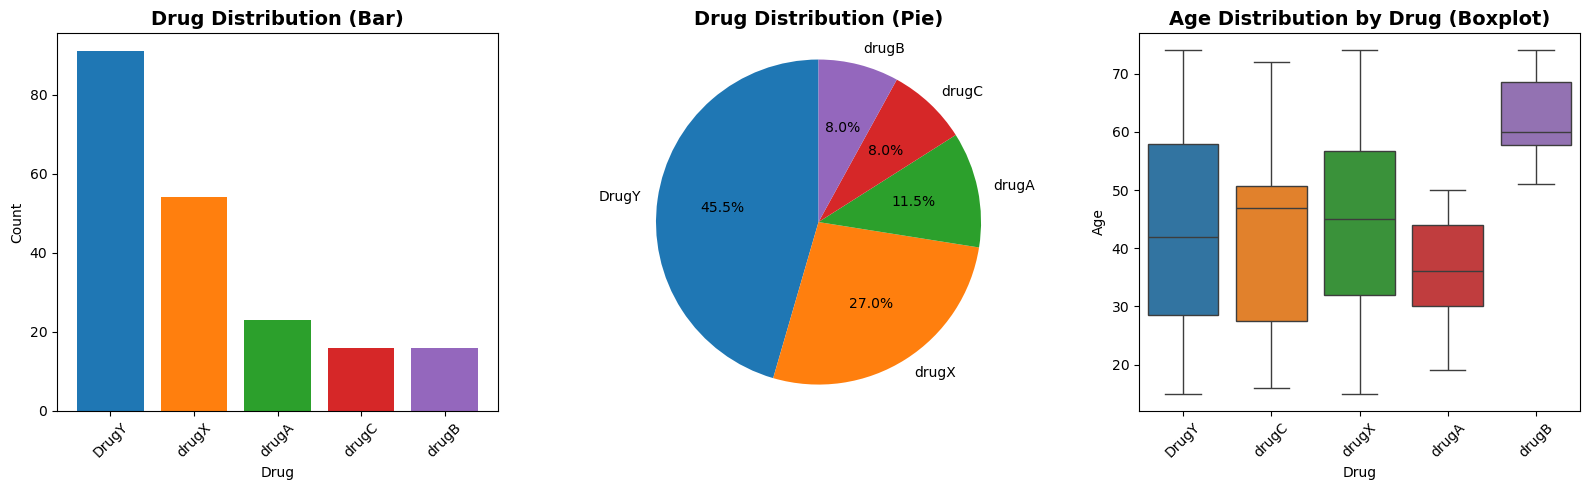

In [305]:
# Count drug occurrences
Drug_counts = df['Drug'].value_counts()

# Create 1 row × 3 columns of subplots
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

#  Bar Chart 
axs[0].set_title('Drug Distribution (Bar)', fontsize=14, fontweight='bold')
axs[0].bar(Drug_counts.index, Drug_counts.values,
           color=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728', '#9467BD'])
axs[0].set_xlabel('Drug')
axs[0].set_ylabel('Count')
axs[0].tick_params(axis='x', rotation=45)

# Pie Chart 
axs[1].set_title('Drug Distribution (Pie)', fontsize=14, fontweight='bold')
axs[1].pie(Drug_counts.values,
           labels=Drug_counts.index,
           autopct='%1.1f%%',
           colors=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728', '#9467BD'],
           startangle=90)
axs[1].axis('equal') 

# Box Plot: Age Distribution by Drug 
axs[2].set_title('Age Distribution by Drug (Boxplot)', fontsize=14, fontweight='bold')
sns.boxplot(x='Drug', y='Age', data=df,
            palette=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728', '#9467BD'],
            ax=axs[2])
axs[2].set_xlabel('Drug')
axs[2].set_ylabel('Age')
axs[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Bivariate Analysis

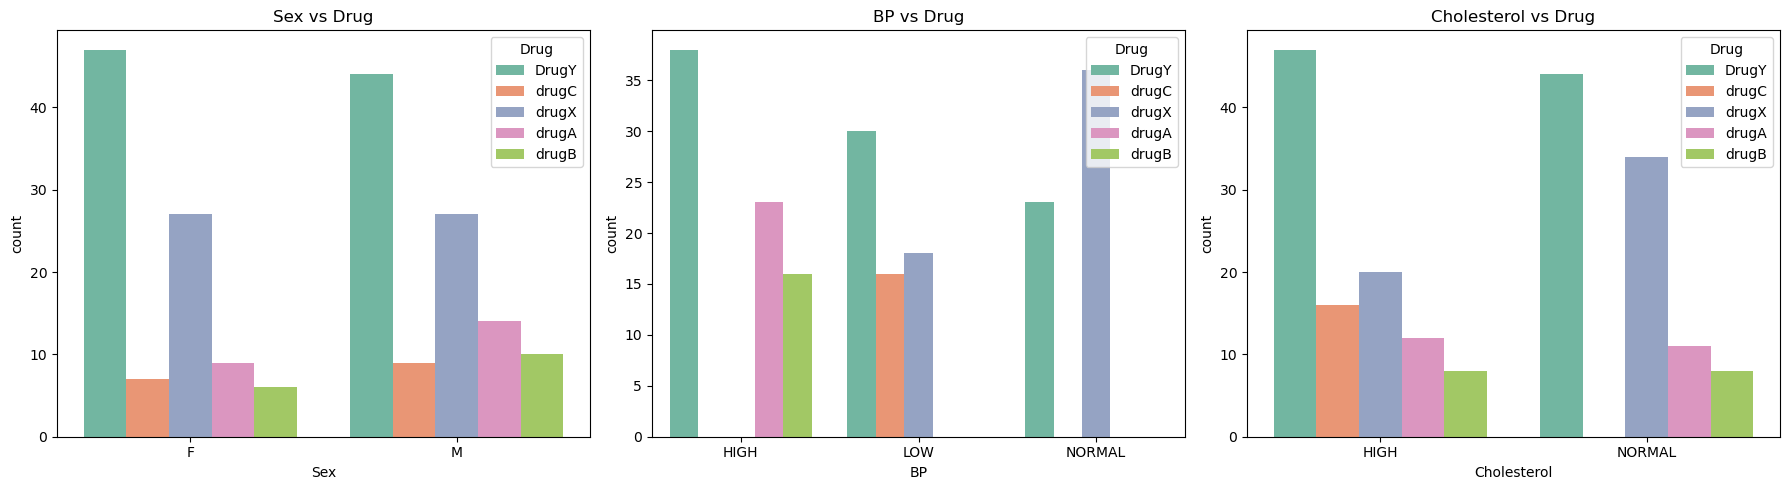

In [307]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(x='Sex', hue='Drug', data=df, palette='Set2')
plt.title('Sex vs Drug')

plt.subplot(1, 3, 2)
sns.countplot(x='BP', hue='Drug', data=df, palette='Set2')
plt.title('BP vs Drug')

plt.subplot(1, 3, 3)
sns.countplot(x='Cholesterol', hue='Drug', data=df, palette='Set2')
plt.title('Cholesterol vs Drug')

plt.tight_layout()
plt.show()

#### Encoding Catergorical variables

In [308]:

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [309]:
# Select all categorical values

categorical_cols =df.select_dtypes(include="object")
categorical_cols.head(2)

,Sex,BP,Cholesterol,Drug
0,F,HIGH,HIGH,DrugY
1,M,LOW,HIGH,drugC


In [310]:
Encoder = LabelEncoder()
df['BP'] = Encoder.fit_transform(df['BP']) 
df['Sex'] = Encoder.fit_transform(df['Sex']) 
df['Cholesterol'] = Encoder.fit_transform(df['Cholesterol']) 
df['Drug'] = Encoder.fit_transform(df['Drug']) 

In [311]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,0
1,47,1,1,0,13.093,3
2,47,1,1,0,10.114,3
3,28,0,2,0,7.798,4
4,61,0,1,0,18.043,0


In [312]:
### Correlation between variables in the data set
df.corr(numeric_only=True)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
Age,1.000000,0.102027,0.054212,-0.068234,-0.063119,0.041856
Sex,0.102027,1.000000,-0.007814,-0.008811,-0.125008,0.018239
BP,0.054212,-0.007814,1.000000,-0.137552,-0.149312,0.419397
Cholesterol,-0.068234,-0.008811,-0.137552,1.000000,0.010000,0.048415
Na_to_K,-0.063119,-0.125008,-0.149312,0.010000,1.000000,-0.689051
Drug,0.041856,0.018239,0.419397,0.048415,-0.689051,1.000000


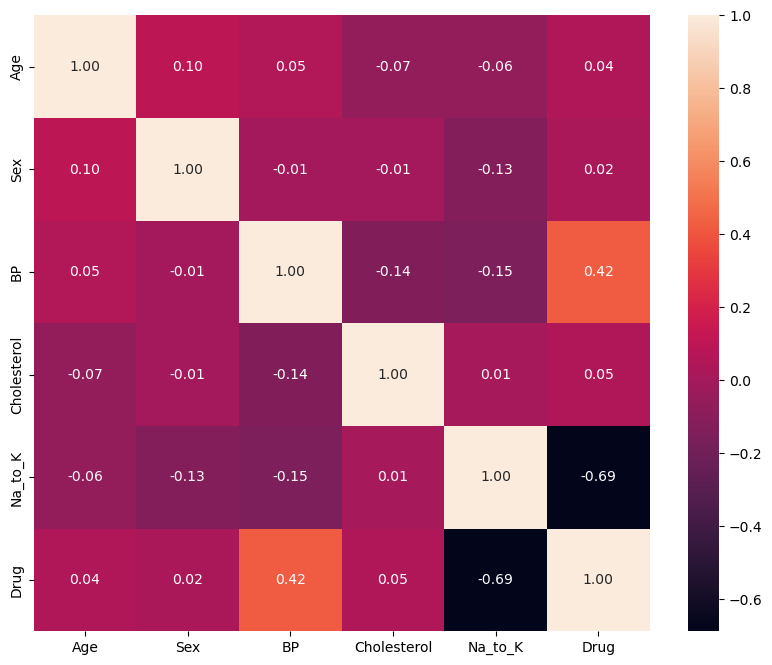

In [313]:
plt.figure(figsize=(10,8))
hm=sns.heatmap(df.corr(numeric_only=True),cbar=True, square=True, fmt='.2f', annot=True)

### Observation

•	The correlation matrix shows the linear relationships among major variables in the dataset, which includes Age, Sex, Blood Pressure (BP), Cholesterol, Sodium-to-Potassium ratio (Na_to_K), and the target variable (Drug). The matrix values range from -1 to +1, where values approaching ±1 indicate stronger linear associations, while values near zero suggest minimal or no linear relationship.

•	Correlation coefficients reveal that Na_to_K and Drug exhibit the strongest relationship (r = -0.69), indicating negative correlation and suggesting that the sodium-to-potassium ratio is a key determinant in predicting the type of drug prescribed. 

•	Blood Pressure (BP) show a moderate positive correlation with Drug (r = 0.42). These findings highlight both Na_to_K and BP as significant predictive features for the drug classification.

•	Conversely, Age, Sex, and Cholesterol show weak correlations with Drug, with r values ranging from 0.02 to 0.05, and also suggesting their limited contribution to drug classification. 


## Modeling Drug Classification Prediction
### Data Pre-processing and Feature Engineering

In [314]:
df.head(2)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,0
1,47,1,1,0,13.093,3


In [315]:
df.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [316]:
### Features and Label

# x = Features
# y = Label

In [317]:
x = df.drop(['Drug'],axis=1) 
y =df[['Drug']]

In [318]:
x.head(1)

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,0,0,0,25.355


In [319]:
y.head(1)

,Drug
0,0


### Data Splitting

In [320]:
print(f"Data contained {len(x)} records before splitting")

Data contained 200 records before splitting


In [321]:
# Splitting Data into Training and Test sets 

from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [322]:
xtrain.head()

,Age,Sex,BP,Cholesterol,Na_to_K
79,32,0,1,1,10.840
197,52,1,2,0,9.894
38,39,0,2,1,9.709
24,33,0,1,0,33.486
122,34,1,2,0,22.456


In [323]:
xtest.head()

,Age,Sex,BP,Cholesterol,Na_to_K
95,36,1,1,1,11.424
15,16,0,0,1,15.516
30,18,0,2,1,8.750
158,59,0,1,0,10.444
128,47,1,1,1,33.542


In [324]:
len(xtest) == len(ytest)

True

In [325]:
len(xtrain) == len(ytrain)

True

In [326]:
len(xtrain) + len(xtest) == len(x)

True

### Model Training

In [327]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Initialize Scaler
scaler = MinMaxScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.fit_transform(xtest)

In [328]:
# Check if scaling is successful the minimum and maximum values for each feature
print("Minimum values per feature:\n", xtrain_scaled.min(axis=0))
print("Maximum values per feature:\n", xtrain_scaled.max(axis=0))

Minimum values per feature:
 [0. 0. 0. 0. 0.]
Maximum values per feature:
 [1. 1. 1. 1. 1.]


#### Initialize and train models

In [329]:
# Defining a base estimator 
base_estimator = DecisionTreeClassifier(random_state=42)

# Initialize all models
Classifiers = [
    [SGDClassifier(random_state=42), 'sdg_model'],
    [DecisionTreeClassifier(random_state=42), 'dt_model'],
    [LogisticRegression(random_state=42, max_iter=1000), 'lr_model'],
    [RandomForestClassifier(random_state=42), 'rf_model'],
    [XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), 'xgb_model'],
    [SVC(random_state=42, probability=True), 'svc_model'],
    [KNeighborsClassifier(), 'knn_model'],
    [GaussianNB(), 'gnb_model'],
    [BaggingClassifier(estimator=base_estimator, random_state=42), 'bagged_model'],  
    [ExtraTreesClassifier(random_state=42), 'et_model'],
    [AdaBoostClassifier(estimator=base_estimator, random_state=42), 'ada_model'],   
    [CatBoostClassifier(verbose=0, random_state=42), 'cat_model'],
    [LGBMClassifier(random_state=42), 'lgbm_model']
]

In [330]:
Classifiers

[[SGDClassifier(random_state=42), 'sdg_model'],
 [DecisionTreeClassifier(random_state=42), 'dt_model'],
 [LogisticRegression(max_iter=1000, random_state=42), 'lr_model'],
 [RandomForestClassifier(random_state=42), 'rf_model'],
 [XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric='logloss',
                feature_types=None, feature_weights=None, gamma=None,
                grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=None, max_bin=None,
                max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=None, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=None, n_jobs=None,
              

<--- sdg_model --->
Classification Report: 
               precision    recall  f1-score   support

           0    0.78947   1.00000   0.88235        15
           1    1.00000   0.83333   0.90909         6
           2    1.00000   0.66667   0.80000         3
           3    1.00000   0.80000   0.88889         5
           4    1.00000   0.90909   0.95238        11

    accuracy                        0.90000        40
   macro avg    0.95789   0.84182   0.88654        40
weighted avg    0.92105   0.90000   0.90026        40

Confusion Matrix: 
 [[15  0  0  0  0]
 [ 1  5  0  0  0]
 [ 1  0  2  0  0]
 [ 1  0  0  4  0]
 [ 1  0  0  0 10]]
Mean Accuracy: 81.25%
Mean Precision: 83.55%
Mean Recall: 81.25%
Mean F1-Score: 80.23%
------------------------------------------------------------


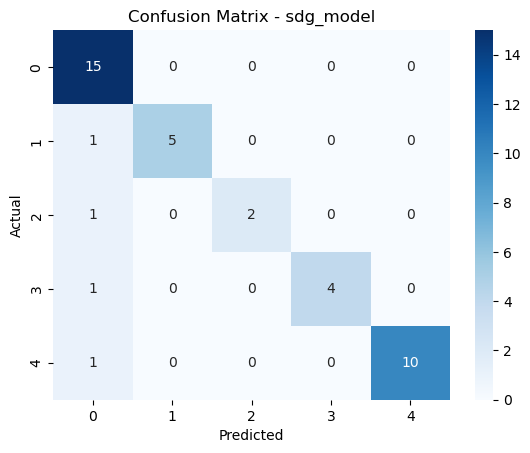

<--- dt_model --->
Classification Report: 
               precision    recall  f1-score   support

           0    1.00000   1.00000   1.00000        15
           1    1.00000   1.00000   1.00000         6
           2    1.00000   1.00000   1.00000         3
           3    1.00000   1.00000   1.00000         5
           4    1.00000   1.00000   1.00000        11

    accuracy                        1.00000        40
   macro avg    1.00000   1.00000   1.00000        40
weighted avg    1.00000   1.00000   1.00000        40

Confusion Matrix: 
 [[15  0  0  0  0]
 [ 0  6  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0  5  0]
 [ 0  0  0  0 11]]
Mean Accuracy: 99.38%
Mean Precision: 99.53%
Mean Recall: 99.38%
Mean F1-Score: 99.36%
------------------------------------------------------------


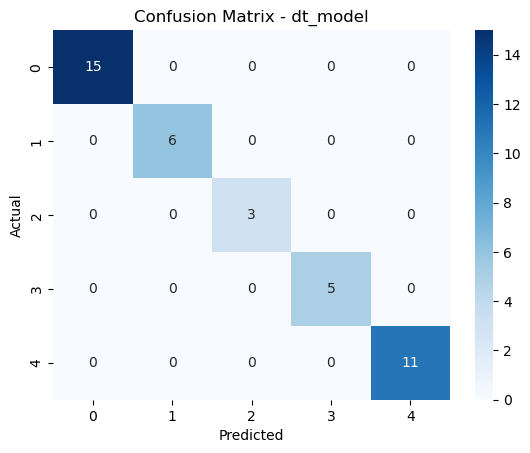

<--- lr_model --->
Classification Report: 
               precision    recall  f1-score   support

           0    0.68182   1.00000   0.81081        15
           1    1.00000   0.66667   0.80000         6
           2    1.00000   0.66667   0.80000         3
           3    0.00000   0.00000   0.00000         5
           4    0.83333   0.90909   0.86957        11

    accuracy                        0.77500        40
   macro avg    0.70303   0.64848   0.65608        40
weighted avg    0.70985   0.77500   0.72318        40

Confusion Matrix: 
 [[15  0  0  0  0]
 [ 2  4  0  0  0]
 [ 1  0  2  0  0]
 [ 3  0  0  0  2]
 [ 1  0  0  0 10]]
Mean Accuracy: 78.75%
Mean Precision: 72.86%
Mean Recall: 78.75%
Mean F1-Score: 74.17%
------------------------------------------------------------


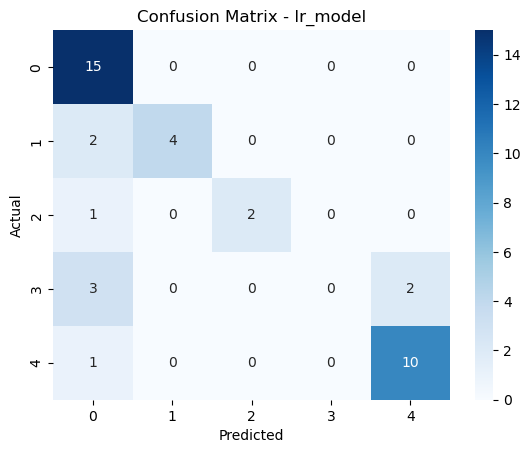

<--- rf_model --->
Classification Report: 
               precision    recall  f1-score   support

           0    0.93750   1.00000   0.96774        15
           1    1.00000   1.00000   1.00000         6
           2    1.00000   1.00000   1.00000         3
           3    1.00000   0.80000   0.88889         5
           4    1.00000   1.00000   1.00000        11

    accuracy                        0.97500        40
   macro avg    0.98750   0.96000   0.97133        40
weighted avg    0.97656   0.97500   0.97401        40

Confusion Matrix: 
 [[15  0  0  0  0]
 [ 0  6  0  0  0]
 [ 0  0  3  0  0]
 [ 1  0  0  4  0]
 [ 0  0  0  0 11]]
Mean Accuracy: 98.75%
Mean Precision: 98.98%
Mean Recall: 98.75%
Mean F1-Score: 98.69%
------------------------------------------------------------


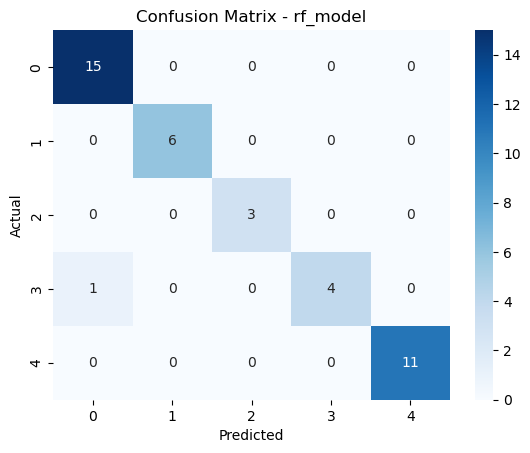

<--- xgb_model --->
Classification Report: 
               precision    recall  f1-score   support

           0    1.00000   1.00000   1.00000        15
           1    1.00000   1.00000   1.00000         6
           2    1.00000   1.00000   1.00000         3
           3    1.00000   0.80000   0.88889         5
           4    0.91667   1.00000   0.95652        11

    accuracy                        0.97500        40
   macro avg    0.98333   0.96000   0.96908        40
weighted avg    0.97708   0.97500   0.97415        40

Confusion Matrix: 
 [[15  0  0  0  0]
 [ 0  6  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0  4  1]
 [ 0  0  0  0 11]]
Mean Accuracy: 97.50%
Mean Precision: 98.00%
Mean Recall: 97.50%
Mean F1-Score: 97.47%
------------------------------------------------------------


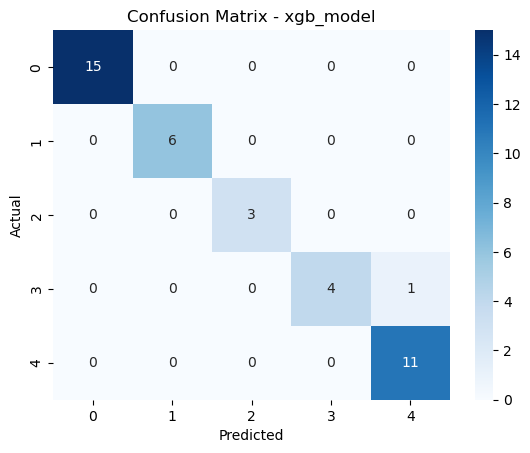

<--- svc_model --->
Classification Report: 
               precision    recall  f1-score   support

           0    0.71429   1.00000   0.83333        15
           1    1.00000   0.66667   0.80000         6
           2    1.00000   1.00000   1.00000         3
           3    1.00000   0.20000   0.33333         5
           4    1.00000   1.00000   1.00000        11

    accuracy                        0.85000        40
   macro avg    0.94286   0.77333   0.79333        40
weighted avg    0.89286   0.85000   0.82417        40

Confusion Matrix: 
 [[15  0  0  0  0]
 [ 2  4  0  0  0]
 [ 0  0  3  0  0]
 [ 4  0  0  1  0]
 [ 0  0  0  0 11]]
Mean Accuracy: 70.62%
Mean Precision: 66.20%
Mean Recall: 70.62%
Mean F1-Score: 66.77%
------------------------------------------------------------


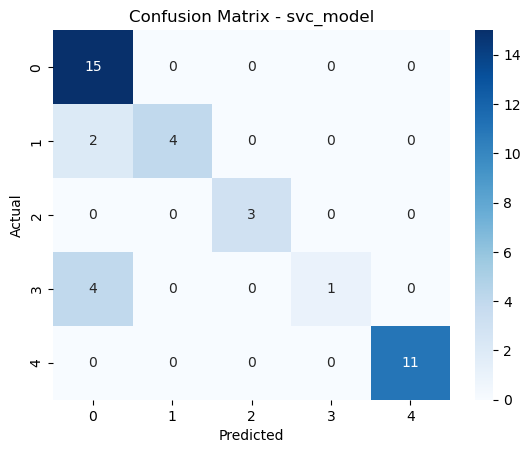

<--- knn_model --->
Classification Report: 
               precision    recall  f1-score   support

           0    0.86667   0.86667   0.86667        15
           1    0.85714   1.00000   0.92308         6
           2    1.00000   1.00000   1.00000         3
           3    1.00000   0.60000   0.75000         5
           4    0.91667   1.00000   0.95652        11

    accuracy                        0.90000        40
   macro avg    0.92810   0.89333   0.89925        40
weighted avg    0.90565   0.90000   0.89526        40

Confusion Matrix: 
 [[13  1  0  0  1]
 [ 0  6  0  0  0]
 [ 0  0  3  0  0]
 [ 2  0  0  3  0]
 [ 0  0  0  0 11]]
Mean Accuracy: 66.88%
Mean Precision: 68.34%
Mean Recall: 66.88%
Mean F1-Score: 65.90%
------------------------------------------------------------


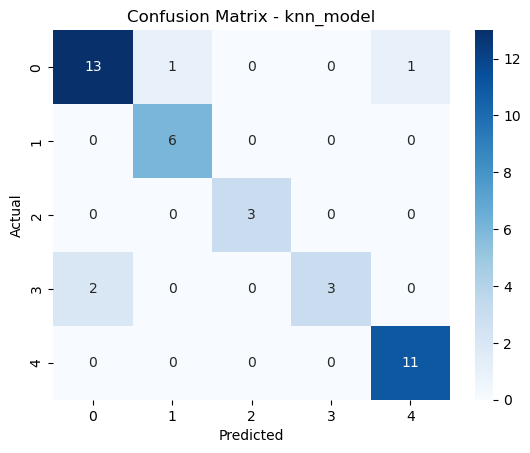

<--- gnb_model --->
Classification Report: 
               precision    recall  f1-score   support

           0    0.92308   0.80000   0.85714        15
           1    0.85714   1.00000   0.92308         6
           2    0.75000   1.00000   0.85714         3
           3    0.83333   1.00000   0.90909         5
           4    1.00000   0.90909   0.95238        11

    accuracy                        0.90000        40
   macro avg    0.87271   0.94182   0.89977        40
weighted avg    0.91014   0.90000   0.89972        40

Confusion Matrix: 
 [[12  1  1  1  0]
 [ 0  6  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0  5  0]
 [ 1  0  0  0 10]]
Mean Accuracy: 81.88%
Mean Precision: 88.71%
Mean Recall: 81.88%
Mean F1-Score: 82.41%
------------------------------------------------------------


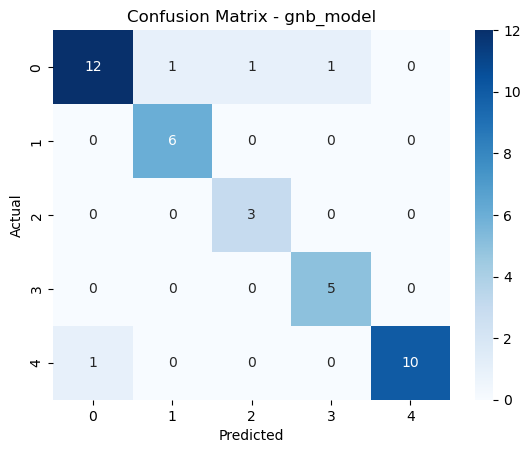

<--- bagged_model --->
Classification Report: 
               precision    recall  f1-score   support

           0    1.00000   1.00000   1.00000        15
           1    1.00000   1.00000   1.00000         6
           2    1.00000   1.00000   1.00000         3
           3    1.00000   1.00000   1.00000         5
           4    1.00000   1.00000   1.00000        11

    accuracy                        1.00000        40
   macro avg    1.00000   1.00000   1.00000        40
weighted avg    1.00000   1.00000   1.00000        40

Confusion Matrix: 
 [[15  0  0  0  0]
 [ 0  6  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0  5  0]
 [ 0  0  0  0 11]]
Mean Accuracy: 99.38%
Mean Precision: 99.53%
Mean Recall: 99.38%
Mean F1-Score: 99.36%
------------------------------------------------------------


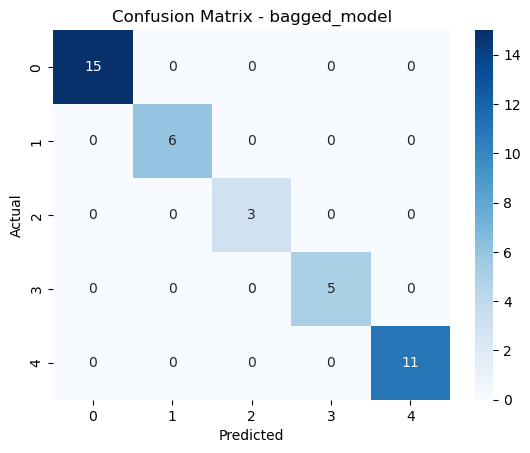

<--- et_model --->
Classification Report: 
               precision    recall  f1-score   support

           0    0.93750   1.00000   0.96774        15
           1    1.00000   0.83333   0.90909         6
           2    1.00000   1.00000   1.00000         3
           3    1.00000   1.00000   1.00000         5
           4    1.00000   1.00000   1.00000        11

    accuracy                        0.97500        40
   macro avg    0.98750   0.96667   0.97537        40
weighted avg    0.97656   0.97500   0.97427        40

Confusion Matrix: 
 [[15  0  0  0  0]
 [ 1  5  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0  5  0]
 [ 0  0  0  0 11]]
Mean Accuracy: 95.00%
Mean Precision: 95.81%
Mean Recall: 95.00%
Mean F1-Score: 94.95%
------------------------------------------------------------


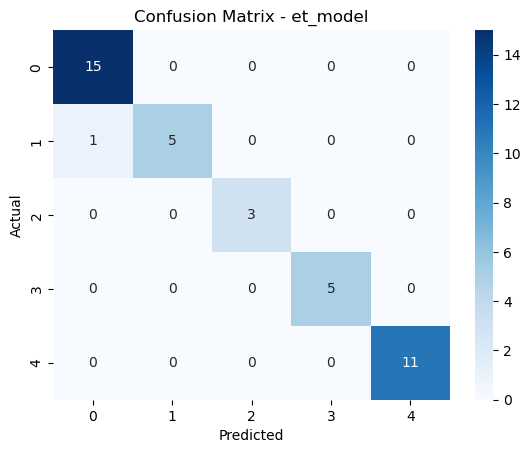

<--- ada_model --->
Classification Report: 
               precision    recall  f1-score   support

           0    1.00000   1.00000   1.00000        15
           1    1.00000   1.00000   1.00000         6
           2    1.00000   1.00000   1.00000         3
           3    1.00000   1.00000   1.00000         5
           4    1.00000   1.00000   1.00000        11

    accuracy                        1.00000        40
   macro avg    1.00000   1.00000   1.00000        40
weighted avg    1.00000   1.00000   1.00000        40

Confusion Matrix: 
 [[15  0  0  0  0]
 [ 0  6  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0  5  0]
 [ 0  0  0  0 11]]
Mean Accuracy: 99.38%
Mean Precision: 99.53%
Mean Recall: 99.38%
Mean F1-Score: 99.36%
------------------------------------------------------------


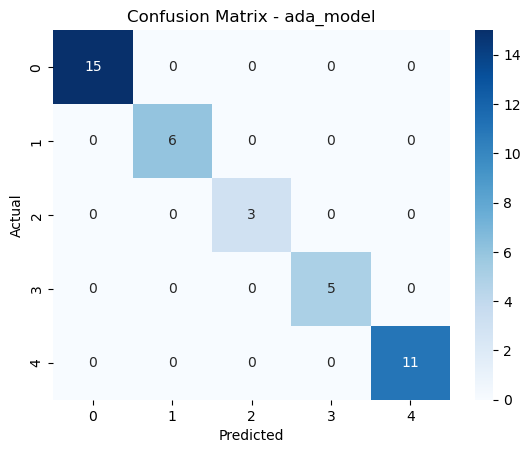

<--- cat_model --->
Classification Report: 
               precision    recall  f1-score   support

           0    1.00000   1.00000   1.00000        15
           1    1.00000   1.00000   1.00000         6
           2    1.00000   1.00000   1.00000         3
           3    1.00000   1.00000   1.00000         5
           4    1.00000   1.00000   1.00000        11

    accuracy                        1.00000        40
   macro avg    1.00000   1.00000   1.00000        40
weighted avg    1.00000   1.00000   1.00000        40

Confusion Matrix: 
 [[15  0  0  0  0]
 [ 0  6  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0  5  0]
 [ 0  0  0  0 11]]
Mean Accuracy: 99.38%
Mean Precision: 99.53%
Mean Recall: 99.38%
Mean F1-Score: 99.36%
------------------------------------------------------------


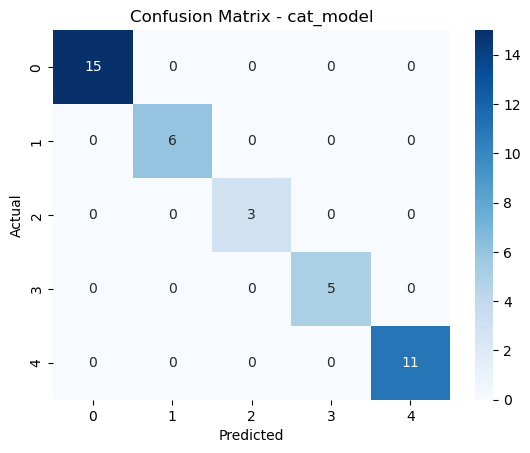

<--- lgbm_model --->
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005796 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 95
[LightGBM] [Info] Number of data points in the train set: 160, number of used features: 5
[LightGBM] [Info] Start training from score -0.744440
[LightGBM] [Info] Start training from score -2.241960
[LightGBM] [Info] Start training from score -2.510224
[LightGBM] [Info] Start training from score -2.677279
[LightGBM] [Info] Start training from score -1.313974
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

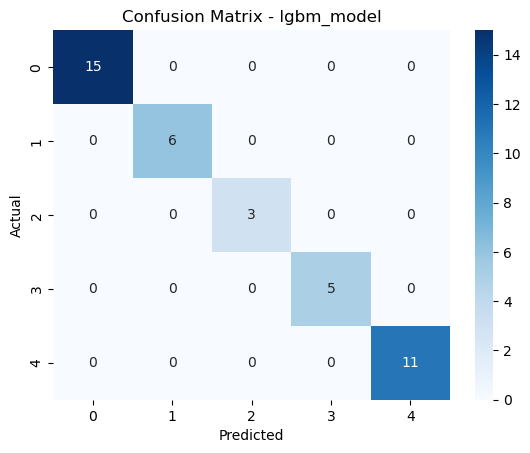

In [338]:
# Choose averaging method
average_method = 'weighted'

# Create empty list to store results
model_results = []

# Evaluate multiple classifiers
for Classifier in Classifiers:
    model = Classifier[0]
    model_name = Classifier[1]
    print(f"<--- {model_name} --->")

    # Fit model
    model.fit(xtrain_scaled, ytrain)
    model_pred = model.predict(xtest_scaled)

    # Classification report & confusion matrix
    report = classification_report(ytest, model_pred, digits=5)
    matrix = confusion_matrix(ytest, model_pred)

    print("Classification Report: \n", report)
    print("Confusion Matrix: \n", matrix)
    
    # Define scoring metrics with weighted average for multiclass
    scoring = {
        'accuracy': 'accuracy',
        'precision': f'precision_{average_method}',
        'recall': f'recall_{average_method}',
        'f1': f'f1_{average_method}',
    }

    # Cross-validation
    cv_results = cross_validate(model, xtrain_scaled, ytrain, cv=5, scoring=scoring)

    # Extract mean scores
    acc = np.mean(cv_results['test_accuracy'])
    prec = np.mean(cv_results['test_precision'])
    rec = np.mean(cv_results['test_recall'])
    f1 = np.mean(cv_results['test_f1'])
    
    # Append to results
    model_results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
    })
    
    # Print mean metrics
    print(f"Mean Accuracy: {acc*100:.2f}%")
    print(f"Mean Precision: {prec*100:.2f}%")
    print(f"Mean Recall: {rec*100:.2f}%")
    print(f"Mean F1-Score: {f1*100:.2f}%")
    print("-" * 60)
    
    # Confusion Matrix Visualization
    sns.heatmap(matrix, annot=True, fmt='g', cmap="Blues")
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [332]:
results_df = pd.DataFrame(model_results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,dt_model,0.99375,0.995313,0.99375,0.993571
1,bagged_model,0.99375,0.995313,0.99375,0.993571
2,ada_model,0.99375,0.995313,0.99375,0.993571
3,cat_model,0.99375,0.995313,0.99375,0.993571
4,rf_model,0.98750,0.989757,0.98750,0.986880
5,lgbm_model,0.98125,0.984028,0.98125,0.981333
6,xgb_model,0.97500,0.980035,0.97500,0.974743
7,et_model,0.95000,0.958099,0.95000,0.949527
8,gnb_model,0.81875,0.887063,0.81875,0.824098
9,sdg_model,0.81250,0.835477,0.81250,0.802305


In [333]:
# Convert results to DataFrame
results_df = pd.DataFrame(model_results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Convert all metric columns to percentages
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    results_df[col] = results_df[col] * 100

# Display DataFrame with percentage metrics
print("\n=== Model Performance Summary (in %) ===")
print(results_df)


=== Model Performance Summary (in %) ===
           Model  Accuracy  Precision  Recall   F1-Score
0       dt_model    99.375  99.531250  99.375  99.357143
1   bagged_model    99.375  99.531250  99.375  99.357143
2      ada_model    99.375  99.531250  99.375  99.357143
3      cat_model    99.375  99.531250  99.375  99.357143
4       rf_model    98.750  98.975694  98.750  98.688025
5     lgbm_model    98.125  98.402778  98.125  98.133302
6      xgb_model    97.500  98.003472  97.500  97.474265
7       et_model    95.000  95.809896  95.000  94.952698
8      gnb_model    81.875  88.706349  81.875  82.409771
9      sdg_model    81.250  83.547702  81.250  80.230500
10      lr_model    78.750  72.858617  78.750  74.166269
11     svc_model    70.625  66.201873  70.625  66.765847
12     knn_model    66.875  68.343022  66.875  65.895739
